#Final Project: CSR Chat Analyzer

###Environment Setup:

In [ ]:
!pip install torch transformers datasets scikit-learn

In [ ]:
import os
import random
import string
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, classification_report

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
    pipeline
)

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW

### Chat Generation

In [ ]:
# ---------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------
NUM_CONVERSATIONS = 1000
OUTPUT_DIR = "conversations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------
# HELPER DATA
# ---------------------------------------------------------------------
issue_types = [
    "billing", "technical_issue", "order_status",
    "cancellation", "account_access", "general_question", "complaint"
]

products = [
    "Premium Plan", "Basic Plan", "Family Package",
    "Cloud Backup", "Streaming Plus", "Mobile App"
]

channels = ["mobile app", "website", "desktop client"]

def random_id(prefix, length=6):
    return prefix + "".join(random.choices(string.ascii_uppercase + string.digits, k=length))

def sample_amount():
    return f"${random.choice([9.99, 14.99, 19.99, 29.99, 49.99, 99.99])}"

def sample_error_code():
    return random.choice(["E101", "E202", "E305", "E408", "E500"])

def sample_order_id():
    return random_id("ORD")

def fill_placeholders(text, product, amount, error_code, order_id, channel):
    return text.format(
        product=product,
        amount=amount,
        error_code=error_code,
        order_id=order_id,
        channel=channel,
    )

# ---------------------------------------------------------------------
# TEMPLATES
# ---------------------------------------------------------------------
customer_openings = {
    "billing": {
        "negative": [
            "I just noticed a charge on my card for {amount} that I do not recognize.",
            "Why was I billed {amount} this month? My plan should cost less.",
            "You double charged me for {product}. I need this fixed now."
        ],
        "neutral": [
            "Hi, I have a question about my latest bill for {amount}.",
            "Can you explain the charges on my invoice for {product}?",
            "I want to review the billing details for my account."
        ],
        "positive": [
            "Hi, the service has been good, but I want to confirm my billing for {product}.",
            "I just upgraded and want to make sure my new bill for {amount} is correct.",
            "Everything has been smooth so far, I just need clarification on one charge."
        ],
    },
    "technical_issue": {
        "negative": [
            "The {product} keeps crashing whenever I try to use it.",
            "I cannot log in to the {channel} at all. This is really frustrating.",
            "Your app is not working and I keep getting error code {error_code}."
        ],
        "neutral": [
            "I am having trouble logging in to the {channel}.",
            "The {product} shows an error code {error_code}. Can you help?",
            "The app is very slow when I try to open my account."
        ],
        "positive": [
            "I like the app, but I ran into a small issue with error code {error_code}.",
            "Things mostly work fine, but I cannot log in from my new device.",
            "Quick question about a minor bug in the {product}."
        ],
    },
    "order_status": {
        "negative": [
            "My order {order_id} is late and still has not arrived.",
            "You said {order_id} would arrive yesterday. Where is it?",
            "Tracking for {order_id} has not updated in days. This is not acceptable."
        ],
        "neutral": [
            "Can you tell me the status of my order {order_id}?",
            "I want an update on the shipping for order {order_id}.",
            "Is there a delay with order {order_id}?"
        ],
        "positive": [
            "Hi, I am checking the status of my recent order {order_id}.",
            "Things have been good so far. When should I expect order {order_id}?",
            "Just verifying delivery details for order {order_id}."
        ],
    },
    "cancellation": {
        "negative": [
            "I want to cancel my {product} immediately. I am not happy with the service.",
            "Please cancel my subscription, I no longer want to use this.",
            "Cancel everything. I am tired of dealing with these issues."
        ],
        "neutral": [
            "I would like to cancel my subscription to {product}.",
            "How do I cancel my account?",
            "Can you help me cancel my plan at the end of this period?"
        ],
        "positive": [
            "I have enjoyed the service, but I need to cancel my {product} for now.",
            "I am pausing some expenses and would like to cancel my plan politely.",
            "Service has been fine, I just need to cancel due to personal reasons."
        ],
    },
    "account_access": {
        "negative": [
            "My account is locked and I cannot access anything.",
            "I keep getting locked out when I try to sign in. This is really annoying.",
            "You disabled my account for no reason and I need it back."
        ],
        "neutral": [
            "I am having trouble signing in to my account.",
            "My password does not seem to work. Can you reset it?",
            "I think my account was locked. How can I regain access?"
        ],
        "positive": [
            "I need a little help resetting my password please.",
            "Can you assist with updating my login details?",
            "Just need guidance to recover access to my account."
        ],
    },
    "general_question": {
        "negative": [
            "Your pricing is confusing and I cannot find any clear information.",
            "Why is it so hard to understand what is included in each plan?",
            "Support pages are not helpful at all. I need answers."
        ],
        "neutral": [
            "I have a question about the features in the {product}.",
            "Can you explain what is included in the {product}?",
            "I want to know if your service supports multiple devices."
        ],
        "positive": [
            "I am interested in upgrading and have a few questions about the features.",
            "The service seems great. Can you tell me more about the {product}?",
            "I want to learn more about what is included in each plan."
        ],
    },
    "complaint": {
        "negative": [
            "I am very unhappy with how my issue was handled last time.",
            "Your support has been terrible. I want to file a complaint.",
            "This is the third time I have contacted you about the same problem."
        ],
        "neutral": [
            "I want to submit feedback about a previous support interaction.",
            "I have a concern about how my last ticket was resolved.",
            "I would like to escalate an issue from a previous chat."
        ],
        "positive": [
            "The last agent tried to help, but my issue is still not resolved.",
            "I appreciate the previous assistance, but I need a bit more help.",
            "I want to give feedback on my last support interaction and follow up."
        ],
    },
}

customer_followups = {
    "negative": [
        "This still does not answer my question.",
        "I am really not satisfied with this response.",
        "This is taking too long and I am losing patience."
    ],
    "neutral": [
        "Thanks, but I still need more details.",
        "I understand, but what does that mean for my account?",
        "Can you clarify that a bit more?"
    ],
    "positive": [
        "That makes sense, thank you.",
        "Great, that helps a lot.",
        "Perfect, I appreciate the clear explanation."
    ],
}

agent_responses = {
    "apology": [
        "I am sorry for the inconvenience and I will do my best to resolve this.",
        "I apologize for the trouble. Let me look into this right away.",
        "I understand your frustration and I am here to help."
    ],
    "clarification": [
        "To clarify, your current plan includes {product} at {amount} per month.",
        "Your order {order_id} is currently in transit and expected to arrive soon.",
        "Our records show that your account is active and linked to this email address."
    ],
    "resolution": [
        "I have issued a credit of {amount} to your account.",
        "I have updated your subscription as requested and sent a confirmation email.",
        "Your password has been reset and a link was sent to your email."
    ],
    "soft_denial": [
        "At this time we are unable to offer a refund, but I can provide a discount for next month.",
        "We cannot cancel the order while it is in transit, but you may refuse delivery.",
        "I am afraid we cannot change that setting, but I can suggest an alternative."
    ],
    "closing_positive": [
        "Is there anything else I can assist you with today?",
        "I am glad we could get this resolved for you.",
        "Thank you for contacting support and have a great day."
    ],
    "closing_negative": [
        "I am sorry we could not fully resolve this today.",
        "I understand this is not the outcome you hoped for.",
        "If you have any further concerns, please reach out again."
    ]
}

# ---------------------------------------------------------------------
# CONVERSATION GENERATOR
# ---------------------------------------------------------------------
def generate_conversation(conv_id):
    issue = random.choice(issue_types)
    product = random.choice(products)
    amount = sample_amount()
    error_code = sample_error_code()
    order_id = sample_order_id()
    channel = random.choice(channels)

    start_sentiment = random.choices(["negative", "neutral", "positive"], weights=[0.5, 0.3, 0.2])[0]
    end_sentiment = random.choices(["negative", "neutral", "positive"], weights=[0.3, 0.3, 0.4])[0]

    num_turns = random.randint(4, 10)
    turns = []
    turn_id = 0

    # Opening
    opening_template = random.choice(customer_openings[issue][start_sentiment])
    opening_text = fill_placeholders(opening_template, product, amount, error_code, order_id, channel)
    turns.append({"conversation_id": conv_id, "turn_id": turn_id, "speaker": "customer", "text": opening_text,
                  "issue_type": issue, "true_sentiment": start_sentiment})
    turn_id += 1

    # Agent reply
    if start_sentiment == "negative":
        agent_msgs = [random.choice(agent_responses["apology"])]
    else:
        agent_msgs = [random.choice(agent_responses["clarification"])]
    if random.random() < 0.6:
        agent_msgs.append(random.choice(agent_responses["resolution"]))

    for msg in agent_msgs:
        agent_text = fill_placeholders(msg, product, amount, error_code, order_id, channel)
        turns.append({"conversation_id": conv_id, "turn_id": turn_id, "speaker": "agent", "text": agent_text,
                      "issue_type": issue, "true_sentiment": None})
        turn_id += 1

    remaining_turns = num_turns - len(turns)
    current_sentiment = start_sentiment

    for _ in range(remaining_turns):
        if turn_id % 2 == 0:
            # customer
            if current_sentiment != end_sentiment and random.random() < 0.4:
                current_sentiment = end_sentiment
            follow_template = random.choice(customer_followups[current_sentiment])
            text = fill_placeholders(follow_template, product, amount, error_code, order_id, channel)
            turns.append({"conversation_id": conv_id, "turn_id": turn_id, "speaker": "customer", "text": text,
                          "issue_type": issue, "true_sentiment": current_sentiment})
        else:
            # agent
            if current_sentiment == "negative":
                pool = agent_responses["apology"] + agent_responses["clarification"]
            elif current_sentiment == "neutral":
                pool = agent_responses["clarification"] + agent_responses["resolution"]
            else:
                pool = agent_responses["resolution"] + agent_responses["closing_positive"]
            text = fill_placeholders(random.choice(pool), product, amount, error_code, order_id, channel)
            turns.append({"conversation_id": conv_id, "turn_id": turn_id, "speaker": "agent", "text": text,
                          "issue_type": issue, "true_sentiment": None})
        turn_id += 1

    # Add final closing
    if turns[-1]["speaker"] == "customer":
        closing = random.choice(
            agent_responses["closing_positive"] if end_sentiment == "positive" else agent_responses["closing_negative"]
        )
        closing_text = fill_placeholders(closing, product, amount, error_code, order_id, channel)
        turns.append({"conversation_id": conv_id, "turn_id": turn_id, "speaker": "agent", "text": closing_text,
                      "issue_type": issue, "true_sentiment": None})

    return turns

# ---------------------------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------------------------
all_turns = []
for i in range(NUM_CONVERSATIONS):
    conv_id = random_id("C")
    conversation = generate_conversation(conv_id)
    all_turns.extend(conversation)

    # Write to .txt file
    convo_text = "\n".join(
        f"{row['speaker'].upper()}: {row['text']}" for row in conversation
    )
    with open(os.path.join(OUTPUT_DIR, f"{conv_id}.txt"), "w", encoding="utf-8") as f:
        f.write(convo_text)

# ---------------------------------------------------------------------
# BUILD DATAFRAME
# ---------------------------------------------------------------------
df = pd.DataFrame(all_turns)
print(df.head(), "\n")
print(f"✅ Generated {df['conversation_id'].nunique()} conversations.")
print(f"✅ Total chat turns: {len(df)}")
print(f"✅ Files saved in: {OUTPUT_DIR}/")


  conversation_id  turn_id   speaker  \
0         CXAJI0Y        0  customer   
1         CXAJI0Y        1     agent   
2         CXAJI0Y        2  customer   
3         CXAJI0Y        3     agent   
4         CXAJI0Y        4  customer   

                                                text      issue_type  \
0  My password does not seem to work. Can you res...  account_access   
1  To clarify, your current plan includes Premium...  account_access   
2      I am really not satisfied with this response.  account_access   
3  I understand your frustration and I am here to...  account_access   
4      I am really not satisfied with this response.  account_access   

  true_sentiment  
0        neutral  
1           None  
2       negative  
3           None  
4       negative   

✅ Generated 1000 conversations.
✅ Total chat turns: 7416
✅ Files saved in: conversations/


### Model Training & Chat Classification

In [ ]:
# New imports needed for this block
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.cuda.amp import autocast, GradScaler

# -------------------------------------------------------------------
# 0) Reproducibility and device
# -------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
if use_cuda:
    print("Device: CUDA")
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
else:
    print("Device: CPU")

# df must already exist from your generator
assert {"speaker", "true_sentiment", "text", "conversation_id"} <= set(df.columns)

# -------------------------------------------------------------------
# 1) Build a 3-class customer-message dataset from your synthetic df
# -------------------------------------------------------------------
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

msg_df = (
    df[df["speaker"] == "customer"][["conversation_id", "text", "true_sentiment"]]
    .dropna(subset=["true_sentiment", "text"])
    .copy()
)
msg_df["label"] = msg_df["true_sentiment"].map(label2id)

# -------------------------------------------------------------------
# 2) Split by conversation_id to avoid leakage
# -------------------------------------------------------------------
convs = msg_df["conversation_id"].unique()
np.random.shuffle(convs)

n = len(convs)
train_convs = convs[: int(0.8 * n)]
val_convs   = convs[int(0.8 * n): int(0.9 * n)]
test_convs  = convs[int(0.9 * n):]

train_df = msg_df[msg_df["conversation_id"].isin(train_convs)].reset_index(drop=True)
val_df   = msg_df[msg_df["conversation_id"].isin(val_convs)].reset_index(drop=True)
test_df  = msg_df[msg_df["conversation_id"].isin(test_convs)].reset_index(drop=True)

print(f"Train msgs: {len(train_df)}  Val msgs: {len(val_df)}  Test msgs: {len(test_df)}")
print("Train label counts:", train_df["label"].value_counts().sort_index().to_dict())

# -------------------------------------------------------------------
# 3) Dataset and DataLoader
# -------------------------------------------------------------------
model_name = "google/mobilebert-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LEN = 192
BATCH_SIZE = 16

class MsgDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int] = None):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

pin = True if use_cuda else False
train_ds = MsgDataset(train_df["text"].tolist(), train_df["label"].tolist())
val_ds   = MsgDataset(val_df["text"].tolist(),   val_df["label"].tolist())
test_ds  = MsgDataset(test_df["text"].tolist(),  test_df["label"].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=pin)

# -------------------------------------------------------------------
# 4) Model, optimizer, scheduler, class weights
# -------------------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)

# Optional class weighting for imbalance
class_counts = train_df["label"].value_counts().sort_index().to_numpy()
class_weights = (class_counts.sum() / np.maximum(class_counts, 1)).astype(np.float32)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float, device=device)
print("Class weights:", class_weights)

EPOCHS = 2   # set to 2 as requested
LR = 5e-5
WARMUP_RATIO = 0.06
TOTAL_STEPS = len(train_loader) * EPOCHS
WARMUP_STEPS = int(TOTAL_STEPS * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=TOTAL_STEPS
)

scaler = GradScaler(enabled=use_cuda)

# -------------------------------------------------------------------
# 5) Train and evaluate with per-epoch progress bars (AMP on GPU)
# -------------------------------------------------------------------
train_loss_history = []
val_loss_history = []
val_f1_history = []

def evaluate(dataloader, split_name="Val"):
    model.eval()
    all_preds, all_labels, losses = [], [], []

    eval_bar = tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False)
    with torch.no_grad():
        for batch in eval_bar:
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            with autocast(enabled=use_cuda):
                outputs = model(**{k: batch[k] for k in ["input_ids", "attention_mask"]})
                logits = outputs.logits
                loss = torch.nn.functional.cross_entropy(logits, batch["labels"], weight=class_weights_t)
            losses.append(loss.item())

            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            labels = batch["labels"].detach().cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

            eval_bar.set_postfix(loss=np.mean(losses))

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")

    print(f"[{split_name}] loss={np.mean(losses):.4f}  acc={acc:.4f}  f1_macro={f1_macro:.4f}")
    print(classification_report(all_labels, all_preds, target_names=[id2label[i] for i in range(3)], digits=3))
    print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))
    return acc, f1_macro, float(np.mean(losses))

best_val_f1 = -1.0
save_dir = "mobilebert_csr_sentiment_3class_gpu"
os.makedirs(save_dir, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []

    # Each epoch has its own visible progress bar
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
    for batch in batch_bar:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        with autocast(enabled=use_cuda):
            outputs = model(**{k: batch[k] for k in ["input_ids", "attention_mask"]})
            logits = outputs.logits
            loss = torch.nn.functional.cross_entropy(logits, batch["labels"], weight=class_weights_t)

        optimizer.zero_grad(set_to_none=True)
        if use_cuda:
            scaler.scale(loss).backward()
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()

        epoch_losses.append(loss.item())
        current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, "get_last_lr") else LR
        batch_bar.set_postfix(train_loss=np.mean(epoch_losses), lr=current_lr)

    train_epoch_loss = float(np.mean(epoch_losses))
    train_loss_history.append(train_epoch_loss)

    # Validation
    _, val_f1, val_loss = evaluate(val_loader, split_name="Val")
    val_f1_history.append(val_f1)
    val_loss_history.append(val_loss)

    # Save best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(save_dir)
        tokenizer.save_pretrained(save_dir)
        print(f"Saved best model to {save_dir} (val F1={best_val_f1:.4f})")

print("\nFinal evaluation on TEST set:")
evaluate(test_loader, split_name="Test")

# Reload best checkpoint for scoring
model = AutoModelForSequenceClassification.from_pretrained(save_dir).to(device)
tokenizer = AutoTokenizer.from_pretrained(save_dir)

# -------------------------------------------------------------------
# 6) Inference helpers and conversation-level aggregation
# -------------------------------------------------------------------
def predict_proba_messages(texts: List[str], batch_size=64) -> np.ndarray:
    ds = MsgDataset(texts, labels=None)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, pin_memory=pin)
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items() if k != "labels"}
            with autocast(enabled=use_cuda):
                logits = model(**batch).logits
            p = torch.softmax(logits, dim=1).detach().cpu().numpy()
            probs.append(p)
    return np.vstack(probs)

def score_conversations(msg_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for cid, g in msg_frame.groupby("conversation_id"):
        p = predict_proba_messages(g["text"].tolist())
        mean_p = p.mean(axis=0)  # [neg, neu, pos]
        pred_class = int(np.argmax(mean_p))
        score_0_100 = float(0.0 * mean_p[0] + 50.0 * mean_p[1] + 100.0 * mean_p[2])

        rows.append({
            "conversation_id": cid,
            "prob_negative": float(mean_p[0]),
            "prob_neutral":  float(mean_p[1]),
            "prob_positive": float(mean_p[2]),
            "predicted_label": id2label[pred_class],
            "customer_sentiment_score": score_0_100
        })
    return pd.DataFrame(rows)

# Compute conversation-level message counts
num_msgs = (
    msg_df.groupby("conversation_id")["text"]
    .count()
    .rename("num_customer_messages")
    .reset_index()
)

# Score conversations
conversation_scores_df = score_conversations(msg_df[["conversation_id", "text"]]).merge(
    num_msgs, on="conversation_id", how="left"
)

print("\nConversation-level scores preview:\n")
print(conversation_scores_df.head())

# Optional save
conversation_scores_df.to_csv("conversation_scores_3class_mobilebert_gpu.csv", index=False)
print("\nSaved conversation scores to conversation_scores_3class_mobilebert_gpu.csv")


Device: CPU
Train msgs: 2520  Val msgs: 313  Test msgs: 298
Train label counts: {0: 1061, 1: 702, 2: 757}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class weights: [0.7666789 1.1587555 1.0745658]


/tmp/ipython-input-1835699081.py:125: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_cuda)


Epoch 1/2:   0%|          | 0/158 [00:00<?, ?it/s]

...

Evaluating Test:   0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipython-input-1835699081.py:142: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):


[Test] loss=0.0000  acc=1.0000  f1_macro=1.0000
              precision    recall  f1-score   support

    negative      1.000     1.000     1.000       123
     neutral      1.000     1.000     1.000        90
    positive      1.000     1.000     1.000        85

    accuracy                          1.000       298
   macro avg      1.000     1.000     1.000       298
weighted avg      1.000     1.000     1.000       298

Confusion matrix:
 [[123   0   0]
 [  0  90   0]
 [  0   0  85]]


/tmp/ipython-input-1835699081.py:231: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_cuda):



Conversation-level scores preview:

  conversation_id  prob_negative  prob_neutral  prob_positive predicted_label  \
0         C00ET7B   9.999906e-01      0.000007   2.671704e-06        negative   
1         C014O46   9.999730e-01      0.000016   1.060090e-05        negative   
2         C03GW7S   1.648513e-08      1.000000   1.332580e-07         neutral   
3         C03TDV0   9.999659e-01      0.000029   4.671995e-06        negative   
4         C04SBRS   3.999944e-01      0.000005   6.000002e-01        positive   

   customer_sentiment_score  num_customer_messages  
0                  0.000597                      5  
1                  0.001878                      2  
2                 50.000004                      4  
3                  0.001937                      2  
4                 60.000290                      5  

Saved conversation scores to conversation_scores_3class_mobilebert_gpu.csv


### Display Results

In [7]:
# -------------------------------------------------------------------
# Display Results — Full Conversation-Level Sentiment Scores
# -------------------------------------------------------------------

# Ensure all rows and columns are displayed
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Full Conversation-Level Sentiment Scores:\n")
print(conversation_scores_df)

# Optional: restore default pandas settings afterward
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")
pd.reset_option("display.width")


Full Conversation-Level Sentiment Scores:

    conversation_id  prob_negative  prob_neutral  prob_positive predicted_label  customer_sentiment_score  num_customer_messages
0           C00ET7B   9.999906e-01  6.602524e-06   2.671704e-06        negative                  0.000597                      5
1           C014O46   9.999730e-01  1.636070e-05   1.060090e-05        negative                  0.001878                      2
2           C03GW7S   1.648513e-08  9.999999e-01   1.332580e-07         neutral                 50.000004                      4
3           C03TDV0   9.999659e-01  2.940592e-05   4.671995e-06        negative                  0.001937                      2
4           C04SBRS   3.999944e-01  5.418390e-06   6.000002e-01        positive                 60.000290                      5
5           C051T8F   6.666665e-01  3.333335e-01   8.977452e-08        negative                 16.666683                      3
6           C05OSZQ   3.333330e-01  1.337009e-05   6.6

### Exploratory Data Analysis

Conversation level evaluation head:

  conversation_id  prob_negative  prob_neutral  prob_positive predicted_label  \
0         C00ET7B   9.999906e-01      0.000007   2.671704e-06        negative   
1         C014O46   9.999730e-01      0.000016   1.060090e-05        negative   
2         C03GW7S   1.648513e-08      1.000000   1.332580e-07         neutral   
3         C03TDV0   9.999659e-01      0.000029   4.671995e-06        negative   
4         C04SBRS   3.999944e-01      0.000005   6.000002e-01        positive   

   customer_sentiment_score  num_customer_messages true_label  
0                  0.000597                      5   negative  
1                  0.001878                      2   negative  
2                 50.000004                      4    neutral  
3                  0.001937                      2   negative  
4                 60.000290                      5   negative   



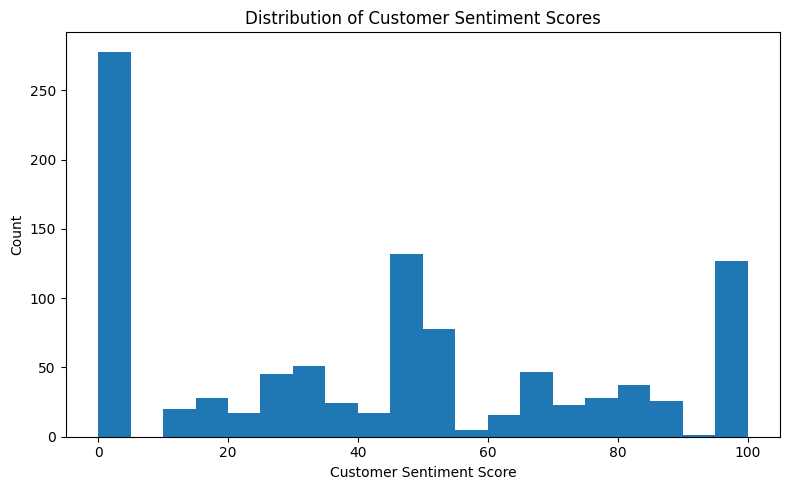

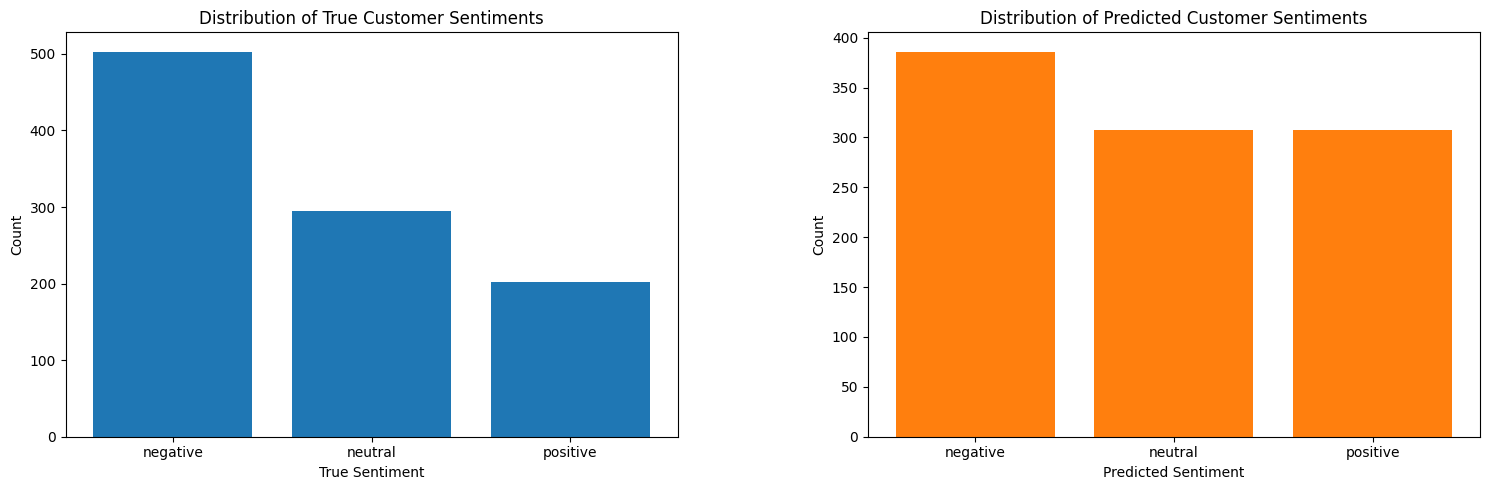

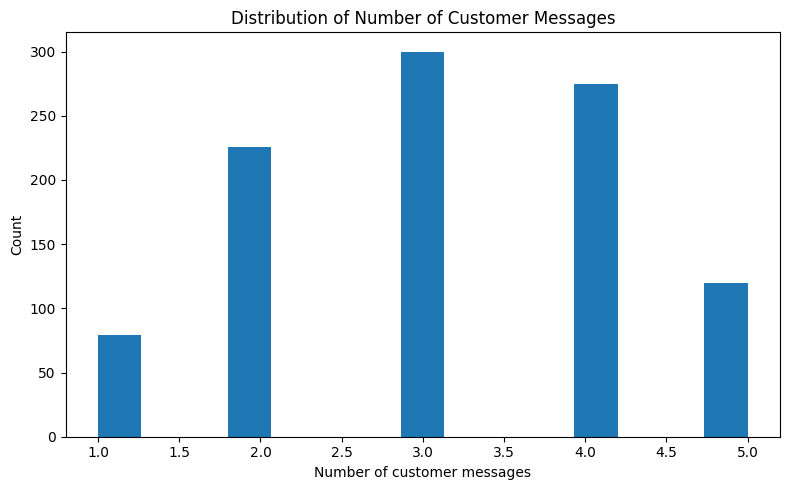



Confusion Matrix (conversation level):

               pred_negative  pred_neutral  pred_positive
true_negative            328            80             95
true_neutral              33           207             55
true_positive             25            20            157 

Classification Report (conversation level):

              precision    recall  f1-score   support

    negative      0.850     0.652     0.738       503
     neutral      0.674     0.702     0.688       295
    positive      0.511     0.777     0.617       202

    accuracy                          0.692      1000
   macro avg      0.678     0.710     0.681      1000
weighted avg      0.730     0.692     0.699      1000



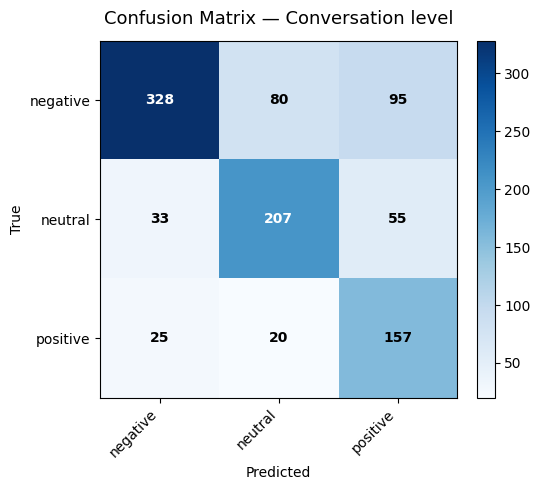

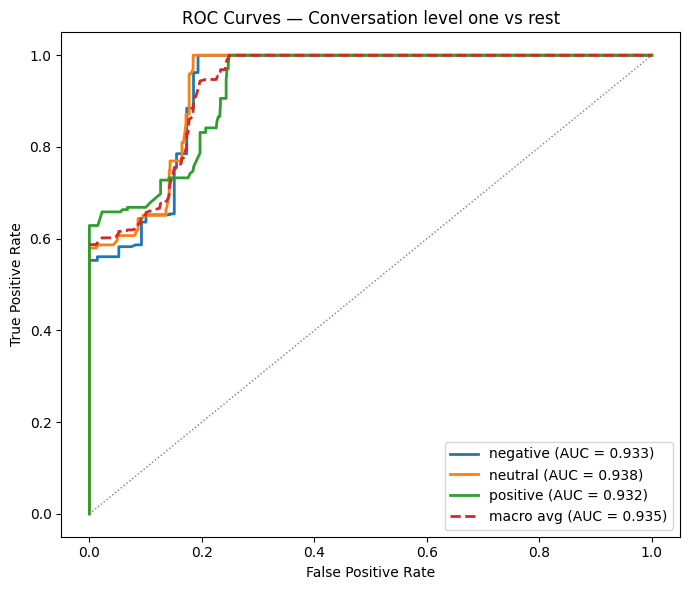

Per class AUC: {'negative': 0.933, 'neutral': 0.938, 'positive': 0.932}
Macro AUC: 0.935

train_loss_history: [401844.706661099, 0.0011477356850991504]
val_loss_history: [1.3657496327823538e-05, 5.721428788518779e-07]


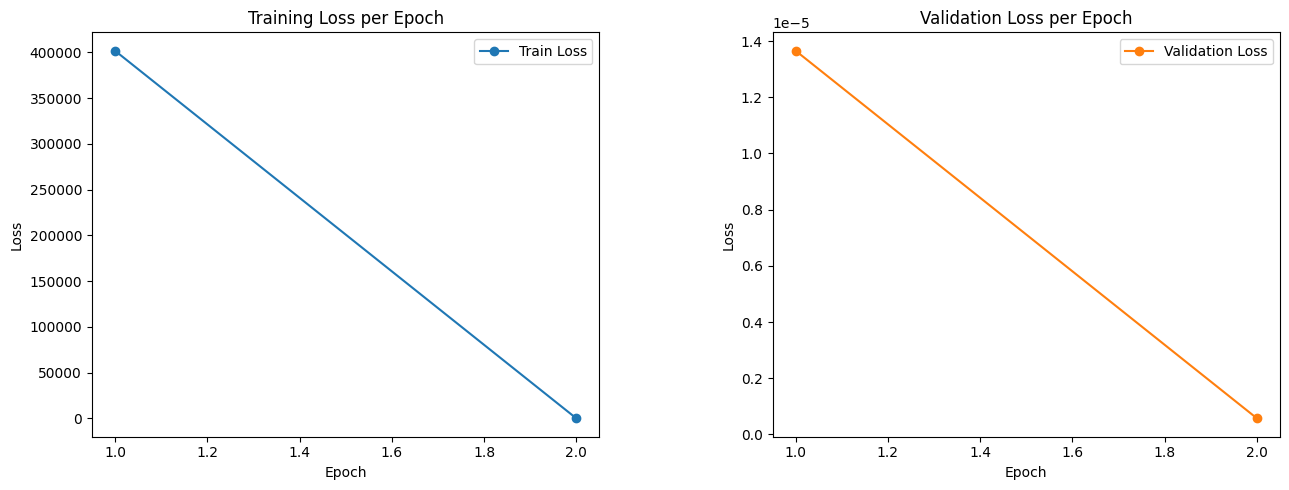

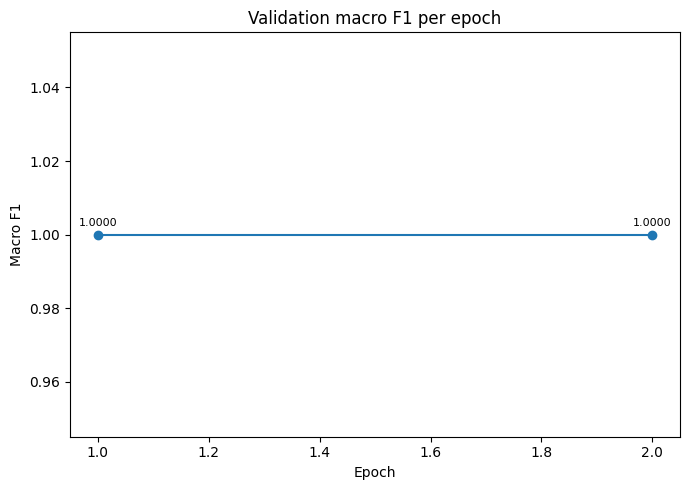

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ---------------------------------------------------------------------
# 0) Build evaluation frame at conversation level
# ---------------------------------------------------------------------
conv_true = (
    df[df["speaker"] == "customer"]
    .groupby("conversation_id")["true_sentiment"]
    .first()
    .reset_index()
    .rename(columns={"true_sentiment": "true_label"})
)

eval_conv = conversation_scores_df.merge(conv_true, on="conversation_id", how="left")

classes = ["negative", "neutral", "positive"]
eval_conv = eval_conv[eval_conv["true_label"].isin(classes)].copy()
eval_conv["predicted_label"] = pd.Categorical(eval_conv["predicted_label"], categories=classes, ordered=True)
eval_conv["true_label"]      = pd.Categorical(eval_conv["true_label"],      categories=classes, ordered=True)

print("Conversation level evaluation head:\n")
print(eval_conv.head(), "\n")

# ---------------------------------------------------------------------
# 1) Feature distributions
# ---------------------------------------------------------------------

# 1a) Histogram of Customer Sentiment Score
plt.figure(figsize=(8, 5))
plt.hist(eval_conv["customer_sentiment_score"], bins=20)
plt.title("Distribution of Customer Sentiment Scores")
plt.xlabel("Customer Sentiment Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("\n")

# 1b + 1c) True vs Predicted label distributions with a visible gap between panels
true_counts = eval_conv["true_label"].value_counts().reindex(classes, fill_value=0)
pred_counts = eval_conv["predicted_label"].value_counts().reindex(classes, fill_value=0)

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.08, 1])  # middle column is a blank spacer

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[2])

# Left: true sentiments
ax1.bar(range(len(classes)), true_counts.values, color="#1f77b4")  # soft blue
ax1.set_xticks(range(len(classes)))
ax1.set_xticklabels(classes, rotation=0)
ax1.set_title("Distribution of True Customer Sentiments")
ax1.set_xlabel("True Sentiment")
ax1.set_ylabel("Count")

# Right: predicted sentiments
ax2.bar(range(len(classes)), pred_counts.values, color="#ff7f0e")  # orange
ax2.set_xticks(range(len(classes)))
ax2.set_xticklabels(classes, rotation=0)
ax2.set_title("Distribution of Predicted Customer Sentiments")
ax2.set_xlabel("Predicted Sentiment")
ax2.set_ylabel("Count")

# Middle gap panel (invisible)
ax_gap = fig.add_subplot(gs[1])
ax_gap.axis("off")

fig.tight_layout()
plt.show()
print("\n")

# 1d) Histogram of number of customer messages per conversation
plt.figure(figsize=(8, 5))
plt.hist(eval_conv["num_customer_messages"], bins=15)
plt.title("Distribution of Number of Customer Messages")
plt.xlabel("Number of customer messages")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("\n")

# ---------------------------------------------------------------------
# 2) Confusion matrix and report (color-coordinated with ROC palette)
# ---------------------------------------------------------------------
from matplotlib import cm

cmatrix = confusion_matrix(eval_conv["true_label"], eval_conv["predicted_label"], labels=classes)
print("Confusion Matrix (conversation level):\n")
print(pd.DataFrame(cmatrix, index=[f"true_{c}" for c in classes],
                   columns=[f"pred_{c}" for c in classes]), "\n")

print("Classification Report (conversation level):\n")
print(classification_report(
    eval_conv["true_label"],
    eval_conv["predicted_label"],
    labels=classes,
    target_names=classes,
    digits=3
))

fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")
im = ax.imshow(cmatrix, interpolation="nearest", cmap=cm.Blues)

ax.set_title("Confusion Matrix — Conversation level", fontsize=13, pad=12, color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right", color="black")
ax.set_yticklabels(classes, color="black")
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("True", color="black")

# Annotate cells with adaptive text color
for i in range(len(classes)):
    for j in range(len(classes)):
        val = cmatrix[i, j]
        pixel_color = im.cmap(im.norm(val))
        luminance = 0.299 * pixel_color[0] + 0.587 * pixel_color[1] + 0.114 * pixel_color[2]
        text_color = "black" if luminance > 0.6 else "white"
        ax.text(j, i, str(val), ha="center", va="center", color=text_color, fontweight="bold")

ax.set_facecolor("white")
fig.patch.set_facecolor("white")
fig.tight_layout()
plt.show()
print("\n")

# ---------------------------------------------------------------------
# 3) ROC curves and AUC scores for 3 classes (one vs rest)
# ---------------------------------------------------------------------
y_true = label_binarize(eval_conv["true_label"].astype(str), classes=classes)
y_prob = eval_conv[["prob_negative", "prob_neutral", "prob_positive"]].to_numpy()

fpr, tpr, roc_auc = {}, {}, {}
for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{cls} (AUC = {roc_auc[i]:.3f})")
plt.plot(all_fpr, mean_tpr, lw=2, linestyle="--", label=f"macro avg (AUC = {macro_auc:.3f})")
plt.plot([0, 1], [0, 1], lw=1, linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Conversation level one vs rest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Per class AUC: {{'negative': {roc_auc[0]:.3f}, 'neutral': {roc_auc[1]:.3f}, 'positive': {roc_auc[2]:.3f}}}")
print(f"Macro AUC: {macro_auc:.3f}\n")

# ---------------------------------------------------------------------
# 4) Training and validation curves with a visible gap between panels
# ---------------------------------------------------------------------
have_train = "train_loss_history" in globals()
have_val   = "val_loss_history" in globals()
have_f1    = "val_f1_history" in globals()

# Quick sanity check
if have_train: print("train_loss_history:", [float(x) for x in train_loss_history])
if have_val:   print("val_loss_history:",   [float(x) for x in val_loss_history])

if have_train or have_val or have_f1:
    epochs_axis = range(1, max(
        len(globals().get("train_loss_history", [])),
        len(globals().get("val_loss_history", [])),
        len(globals().get("val_f1_history", []))
    ) + 1)

    # Side-by-side loss plots with a real gap between them
    if have_train or have_val:
        fig = plt.figure(figsize=(13, 5))
        gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.08, 1])  # middle = spacer

        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[2])

        if have_train:
            ax1.plot(epochs_axis[:len(train_loss_history)], train_loss_history,
                     marker="o", color="#1f77b4", label="Train Loss")
        ax1.set_title("Training Loss per Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.legend()

        if have_val:
            ax2.plot(epochs_axis[:len(val_loss_history)], val_loss_history,
                     marker="o", color="#ff7f0e", label="Validation Loss")
        ax2.set_title("Validation Loss per Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Loss")
        ax2.legend()

        # Middle gap panel
        ax_gap = fig.add_subplot(gs[1])
        ax_gap.axis("off")

        fig.tight_layout()
        plt.show()
        print("\n")

    # Optional: F1 curve
    if have_f1 and len(val_f1_history) > 0:
        plt.figure(figsize=(7, 5))
        plt.plot(epochs_axis[:len(val_f1_history)], val_f1_history, marker="o")
        for i, v in enumerate(val_f1_history, start=1):
            plt.annotate(f"{v:.4f}", (i, v), textcoords="offset points", xytext=(0,6), ha="center", fontsize=8)
        plt.title("Validation macro F1 per epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Macro F1")
        plt.tight_layout()
        plt.show()
else:
    print("Training curves not plotted because train_loss_history, val_loss_history, or val_f1_history were not found.")
